# IPO Variant Deep Comparison

이 notebook은 기존 benchmark 비교를 넘어서, fixed-ratio IPO와 length-normalized IPO가 실제로 어떻게 다르게 동작했는지 확인하기 위한 추가 분석용입니다.

포함된 비교:

1. Benchmark delta heatmap
2. Train/eval actual ratio curve
3. Validation actual ratio histogram
4. Response length difference vs policy gap scatter
5. Layer-wise weight delta norm

무거운 계산은 `outputs/analysis_ipo_variants/` 아래 CSV로 캐시합니다.

In [1]:
from pathlib import Path
import os

ROOT = Path.cwd()
ANALYSIS_ROOT = ROOT / "outputs" / "analysis_ipo_variants"
ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)

# Avoid root-owned default HF cache / wandb directories.
os.environ["HF_HOME"] = str(ROOT / ".hf_cache")
os.environ["HF_DATASETS_CACHE"] = str(ROOT / ".hf_cache" / "datasets")
os.environ["PYTHONDONTWRITEBYTECODE"] = "1"

import gc
import json
import math
import re
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    sns = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

BENCHMARK_CSV = ROOT / "outputs" / "eval_trained_ipo_variants" / "benchmark_comparison.csv"
TRAINING_SUMMARY_CSV = ROOT / "outputs" / "eval_trained_ipo_variants" / "training_log_summary.csv"
FIXED_RATIO_ROOT = ROOT / "outputs" / "fixed_ratio_ipo"
LENGTH_NORM_ROOT = ROOT / "outputs" / "length_normalized_ipo" / "20260607"
SFT_MODEL_ID = "AIPlans/Qwen3-0.6b-SFT-hs2"
DATASET_ID = "Jennny/helpsteer2-helpfulness-preference"
BETA = 0.01

def show_path(p):
    return str(p.relative_to(ROOT)) if isinstance(p, Path) and p.is_relative_to(ROOT) else str(p)

In [2]:
def discover_models():
    rows = []
    for ratio in [0.6, 0.7, 0.8]:
        run_dir = FIXED_RATIO_ROOT / f"ratio_{ratio:.1f}_e3_bs8_beta0.01_lr5e-7"
        rows.append({
            "model": f"ratio={ratio:.1f}",
            "family": "fixed_ratio",
            "objective": "target_ratio",
            "length_norm": "none",
            "target_ratio": ratio,
            "model_path": run_dir / "final",
            "run_dir": run_dir,
            "safe_name": f"ratioeq{ratio:.1f}",
        })

    if LENGTH_NORM_ROOT.exists():
        for run_dir in sorted(LENGTH_NORM_ROOT.iterdir()):
            if not run_dir.is_dir():
                continue
            name = run_dir.name
            m = re.search(r"objective_target_ratio_norm_(?P<norm>[^_]+)_ratio_(?P<ratio>[0-9.]+)_", name)
            if m:
                norm = m.group("norm")
                ratio = float(m.group("ratio"))
                rows.append({
                    "model": f"target_ratio+{norm}={ratio:.1f}",
                    "family": "length_normalized",
                    "objective": "target_ratio",
                    "length_norm": norm,
                    "target_ratio": ratio,
                    "model_path": run_dir / "final",
                    "run_dir": run_dir,
                    "safe_name": f"target_ratioplus{norm}eq{ratio:.1f}",
                })
                continue
            m = re.search(r"objective_standard_ipo_norm_(?P<norm>[^_]+)_", name)
            if m:
                norm = m.group("norm")
                rows.append({
                    "model": f"standard_ipo+{norm}",
                    "family": "length_normalized",
                    "objective": "standard_ipo",
                    "length_norm": norm,
                    "target_ratio": np.nan,
                    "model_path": run_dir / "final",
                    "run_dir": run_dir,
                    "safe_name": f"standard_ipoplus{norm}",
                })
    models = pd.DataFrame(rows)
    models = models[models["model_path"].map(lambda p: Path(p).exists())].reset_index(drop=True)
    return models

models = discover_models()
models[["model", "family", "objective", "length_norm", "target_ratio", "model_path"]]

,model,family,objective,length_norm,target_ratio,model_path
0,ratio=0.6,fixed_ratio,target_ratio,none,0.6,/home/cvip/qwen3_ipo_exp/outputs/fixed_ratio_i...
1,ratio=0.7,fixed_ratio,target_ratio,none,0.7,/home/cvip/qwen3_ipo_exp/outputs/fixed_ratio_i...
2,ratio=0.8,fixed_ratio,target_ratio,none,0.8,/home/cvip/qwen3_ipo_exp/outputs/fixed_ratio_i...
3,standard_ipo+mean,length_normalized,standard_ipo,mean,NaN,/home/cvip/qwen3_ipo_exp/outputs/length_normal...
4,standard_ipo+sqrt,length_normalized,standard_ipo,sqrt,NaN,/home/cvip/qwen3_ipo_exp/outputs/length_normal...
5,target_ratio+mean=0.7,length_normalized,target_ratio,mean,0.7,/home/cvip/qwen3_ipo_exp/outputs/length_normal...
6,target_ratio+mean=0.8,length_normalized,target_ratio,mean,0.8,/home/cvip/qwen3_ipo_exp/outputs/length_normal...
7,target_ratio+sqrt=0.7,length_normalized,target_ratio,sqrt,0.7,/home/cvip/qwen3_ipo_exp/outputs/length_normal...
8,target_ratio+sqrt=0.8,length_normalized,target_ratio,sqrt,0.8,/home/cvip/qwen3_ipo_exp/outputs/length_normal...


## 1. Benchmark Delta Heatmap

기준 모델 대비 task별 delta를 heatmap으로 봅니다. 기본 기준은 기존 IPO입니다.

In [3]:
benchmark = pd.read_csv(BENCHMARK_CSV)
benchmark

,Task,Metric,IPO,DPO,ratio=0.6,ratio=0.7,ratio=0.8,standard_ipo+mean,standard_ipo+sqrt,target_ratio+mean=0.7,target_ratio+mean=0.8,target_ratio+sqrt=0.7,target_ratio+sqrt=0.8
0,ARC-Challenge,acc_norm,0.3968,0.3430,0.4027,0.4087,0.4044,0.3933,0.3993,0.3908,0.3993,0.4019,0.3985
1,ARC-Easy,acc_norm,0.6700,0.5589,0.6612,0.6498,0.6389,0.6423,0.6271,0.5934,0.6237,0.6242,0.6275
2,HellaSwag,acc_norm,0.5540,0.4740,0.5650,0.5681,0.5707,0.5572,0.5605,0.5541,0.5571,0.5580,0.5580
3,TruthfulQA MC2,acc,0.4576,0.4305,0.4789,0.4904,0.4957,0.4937,0.4940,0.4864,0.4903,0.4953,0.4946
4,Winogrande,acc,0.5935,0.5620,0.5848,0.5746,0.5770,0.5722,0.5730,0.5722,0.5793,0.5667,0.5730


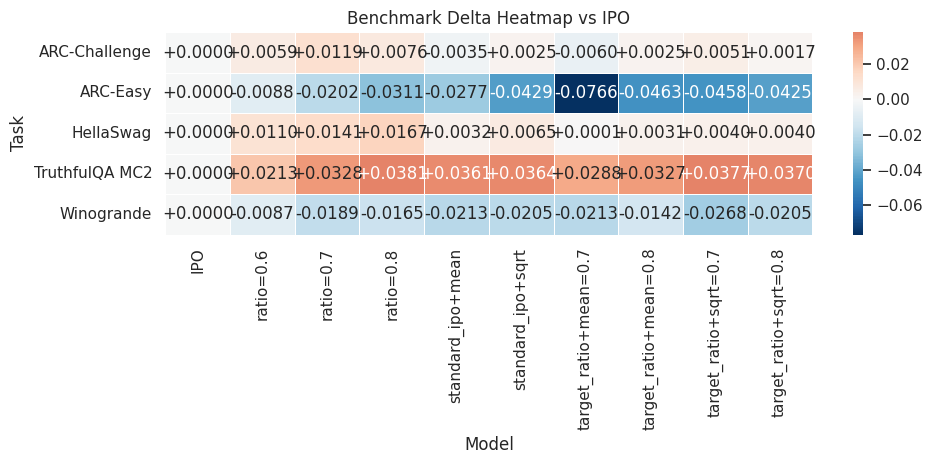

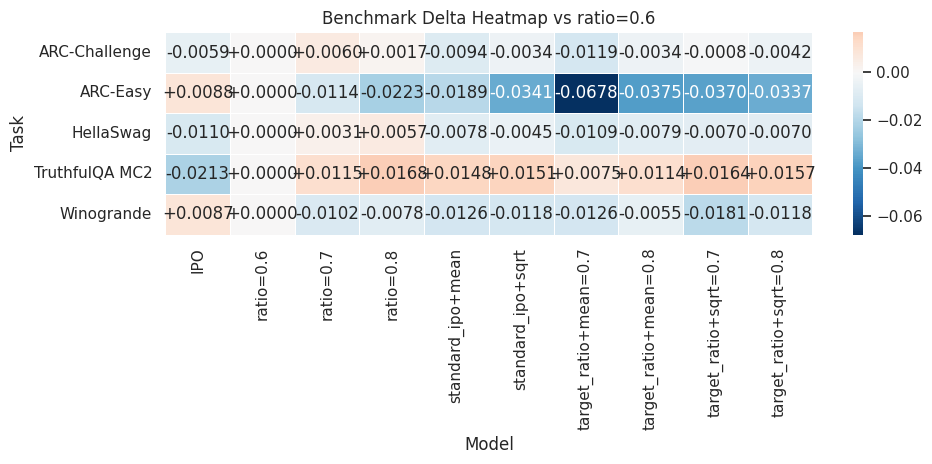

In [4]:
def plot_benchmark_delta_heatmap(baseline="IPO", include_dpo=False):
    df = benchmark.copy()
    id_cols = ["Task", "Metric"]
    model_cols = [c for c in df.columns if c not in id_cols]
    if not include_dpo:
        model_cols = [c for c in model_cols if c != "DPO"]
    if baseline not in model_cols and baseline not in df.columns:
        raise ValueError(f"baseline {baseline!r} not found")

    delta = df[model_cols].sub(df[baseline], axis=0)
    delta.index = df["Task"]

    plt.figure(figsize=(max(10, 0.9 * len(model_cols)), 4.8))
    if sns:
        sns.heatmap(delta, annot=True, fmt="+.4f", cmap="RdBu_r", center=0, linewidths=0.5)
    else:
        plt.imshow(delta.values, cmap="RdBu_r", aspect="auto")
        plt.colorbar(label=f"Delta vs {baseline}")
        plt.xticks(range(len(model_cols)), model_cols, rotation=45, ha="right")
        plt.yticks(range(len(delta.index)), delta.index)
    plt.title(f"Benchmark Delta Heatmap vs {baseline}")
    plt.xlabel("Model")
    plt.ylabel("Task")
    plt.tight_layout()
    plt.show()

plot_benchmark_delta_heatmap(baseline="IPO", include_dpo=False)
plot_benchmark_delta_heatmap(baseline="ratio=0.6", include_dpo=False)

## 2. Train/Eval Actual Ratio Curve

`trainer_state.json`의 log history에서 train/eval actual ratio를 꺼내 학습 중 target ratio를 얼마나 따라갔는지 비교합니다.

In [5]:
def latest_trainer_state(run_dir):
    states = sorted(Path(run_dir).glob("checkpoint-*/trainer_state.json"), key=lambda p: int(re.search(r"checkpoint-(\d+)", str(p)).group(1)))
    return states[-1] if states else None

def load_ratio_curve(models_df):
    rows = []
    for _, meta in models_df.iterrows():
        state_path = latest_trainer_state(meta["run_dir"])
        if state_path is None:
            continue
        state = json.loads(Path(state_path).read_text())
        for row in state.get("log_history", []):
            step = row.get("step")
            if step is None:
                continue
            if "target_ratio/actual" in row:
                rows.append({
                    "model": meta["model"],
                    "family": meta["family"],
                    "objective": meta["objective"],
                    "length_norm": meta["length_norm"],
                    "target_ratio": meta["target_ratio"],
                    "split": "train",
                    "step": step,
                    "actual_ratio": row.get("target_ratio/actual"),
                    "target": row.get("target_ratio/target"),
                    "loss": row.get("loss"),
                    "reward_accuracy": row.get("rewards/accuracies"),
                })
            if "eval_target_ratio/actual" in row:
                rows.append({
                    "model": meta["model"],
                    "family": meta["family"],
                    "objective": meta["objective"],
                    "length_norm": meta["length_norm"],
                    "target_ratio": meta["target_ratio"],
                    "split": "eval",
                    "step": step,
                    "actual_ratio": row.get("eval_target_ratio/actual"),
                    "target": row.get("eval_target_ratio/target"),
                    "loss": row.get("eval_loss"),
                    "reward_accuracy": row.get("eval_rewards/accuracies"),
                })
    return pd.DataFrame(rows)

ratio_curve = load_ratio_curve(models)
ratio_curve.to_csv(ANALYSIS_ROOT / "train_eval_actual_ratio_curve.csv", index=False)
ratio_curve.tail()

,model,family,objective,length_norm,target_ratio,split,step,actual_ratio,target,loss,reward_accuracy
2677,target_ratio+sqrt=0.8,length_normalized,target_ratio,sqrt,0.8,train,2680,0.561652,0.8,1.335053,0.91250
2678,target_ratio+sqrt=0.8,length_normalized,target_ratio,sqrt,0.8,train,2690,0.548922,0.8,1.475392,0.80000
2679,target_ratio+sqrt=0.8,length_normalized,target_ratio,sqrt,0.8,train,2700,0.564378,0.8,1.319099,0.85000
2680,target_ratio+sqrt=0.8,length_normalized,target_ratio,sqrt,0.8,eval,2700,0.502102,0.8,1.967469,0.54734
2681,target_ratio+sqrt=0.8,length_normalized,target_ratio,sqrt,0.8,eval,2709,0.502327,0.8,1.964205,0.55266


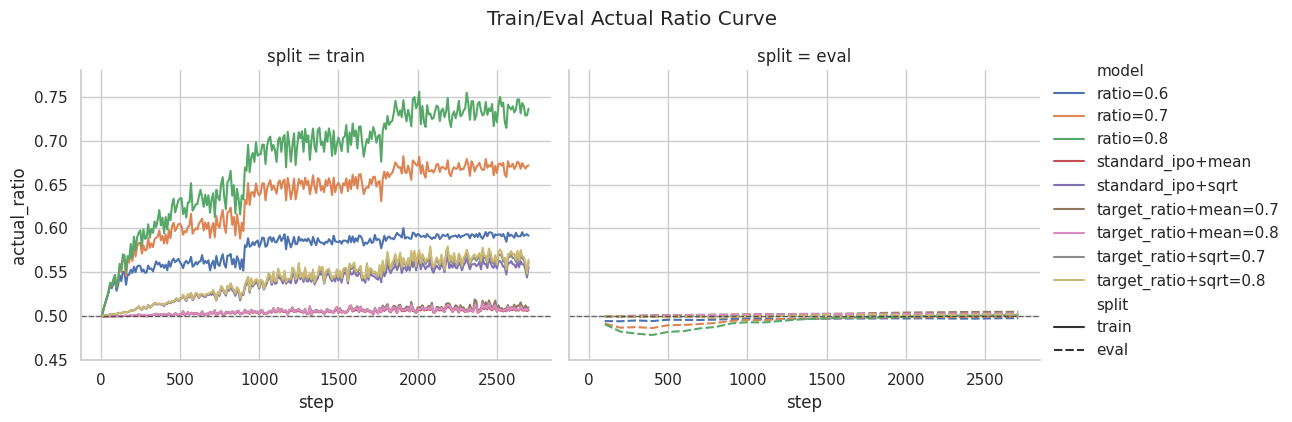

In [6]:
def plot_actual_ratio_curves(model_filter=None):
    df = ratio_curve.copy()
    if model_filter is not None:
        df = df[df["model"].isin(model_filter)]
    g = sns.relplot(
        data=df,
        x="step",
        y="actual_ratio",
        hue="model",
        style="split",
        col="split",
        kind="line",
        height=4,
        aspect=1.35,
        facet_kws={"sharey": True},
    ) if sns else None
    if sns:
        for ax in g.axes.flat:
            ax.axhline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.5)
            ax.set_ylim(0.45, 0.78)
        g.figure.suptitle("Train/Eval Actual Ratio Curve", y=1.05)
        plt.show()
    else:
        for split, split_df in df.groupby("split"):
            plt.figure(figsize=(10, 4))
            for model, mdf in split_df.groupby("model"):
                plt.plot(mdf["step"], mdf["actual_ratio"], label=model)
            plt.axhline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.5)
            plt.title(f"{split} actual ratio")
            plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
            plt.tight_layout()
            plt.show()

plot_actual_ratio_curves()

## 3. Validation Actual Ratio Histogram / 4. Length Difference vs Policy Gap Scatter

아래 셀은 validation pair에서 각 모델의 chosen/rejected logprob를 직접 계산합니다.

- `actual_ratio = sigmoid(beta * ((policy_chosen - policy_rejected) - (ref_chosen - ref_rejected)))`
- length norm 모델은 학습 때와 같은 방식으로 logprob를 `mean` 또는 `sqrt(length)`로 정규화합니다.
- 첫 실행은 모델을 순차적으로 로드하므로 시간이 걸립니다.
- 결과는 `outputs/analysis_ipo_variants/validation_pair_metrics.csv`로 저장됩니다.

In [7]:
# 처음에는 작게 시작하는 것을 권장합니다. 더 자세히 보려면 256 또는 전체 validation 길이로 늘리세요.
N_EVAL_PAIRS = 128
BATCH_SIZE = 2
FORCE_RECOMPUTE_VALIDATION = False

# 너무 오래 걸리면 여기서 비교 모델을 줄일 수 있습니다.
VALIDATION_MODELS = [
    "ratio=0.6",
    "ratio=0.7",
    "ratio=0.8",
    "standard_ipo+mean",
    "standard_ipo+sqrt",
    "target_ratio+mean=0.7",
    "target_ratio+mean=0.8",
    "target_ratio+sqrt=0.7",
    "target_ratio+sqrt=0.8",
]

In [8]:
def build_chat_texts(tokenizer, messages):
    prompt_messages = messages[:-1]
    try:
        full_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        prompt_text = tokenizer.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        prompt_text = "\n".join(f"{m['role']}: {m['content']}" for m in prompt_messages) + "\nassistant: "
        full_text = prompt_text + messages[-1]["content"]
    return prompt_text, full_text

def encode_pair_rows(tokenizer, rows):
    texts = []
    prompt_lens = []
    kinds = []
    pair_ids = []
    for pair_id, row in enumerate(rows):
        for kind in ["chosen", "rejected"]:
            prompt_text, full_text = build_chat_texts(tokenizer, row[kind])
            full_ids = tokenizer(full_text, add_special_tokens=False).input_ids
            prompt_ids = tokenizer(prompt_text, add_special_tokens=False).input_ids
            prompt_len = min(len(prompt_ids), len(full_ids) - 1)
            texts.append(full_text)
            prompt_lens.append(prompt_len)
            kinds.append(kind)
            pair_ids.append(pair_id)
    enc = tokenizer(texts, add_special_tokens=False, padding=True, truncation=True, max_length=1024, return_tensors="pt")
    completion_mask = enc["attention_mask"].clone()
    for i, prompt_len in enumerate(prompt_lens):
        completion_mask[i, :prompt_len] = 0
    return enc, completion_mask, pair_ids, kinds

@torch.no_grad()
def compute_logps_for_rows(model, tokenizer, rows, batch_size=2, device="cuda"):
    out = []
    model.eval()
    for start in range(0, len(rows), batch_size):
        batch_rows = rows[start:start + batch_size]
        enc, completion_mask, pair_ids, kinds = encode_pair_rows(tokenizer, batch_rows)
        enc = {k: v.to(device) for k, v in enc.items()}
        completion_mask = completion_mask.to(device)
        outputs = model(**enc, use_cache=False)
        logits = outputs.logits[:, :-1, :]
        labels = enc["input_ids"][:, 1:]
        mask = completion_mask[:, 1:]
        token_logps = torch.log_softmax(logits.float(), dim=-1).gather(-1, labels.unsqueeze(-1)).squeeze(-1)
        token_logps = token_logps * mask
        seq_logps = token_logps.sum(dim=1).detach().cpu().numpy()
        lengths = mask.sum(dim=1).detach().cpu().numpy()
        for j, (local_pair_id, kind) in enumerate(zip(pair_ids, kinds)):
            out.append({
                "pair_id": start + local_pair_id,
                "kind": kind,
                "logp": float(seq_logps[j]),
                "length": int(lengths[j]),
            })
    return pd.DataFrame(out)

def pivot_logps(df, prefix):
    wide = df.pivot(index="pair_id", columns="kind", values=["logp", "length"])
    wide.columns = [f"{prefix}_{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index()
    return wide

In [9]:
def compute_validation_pair_metrics(models_df, selected_models, n_pairs=128, batch_size=2, force=False):
    cache_path = ANALYSIS_ROOT / "validation_pair_metrics.csv"
    if cache_path.exists() and not force:
        cached = pd.read_csv(cache_path)
        have = set(cached["model"].unique())
        if set(selected_models).issubset(have) and cached["pair_id"].nunique() >= n_pairs:
            return cached[cached["model"].isin(selected_models) & (cached["pair_id"] < n_pairs)].copy()

    import torch
    from datasets import load_dataset
    from transformers import AutoModelForCausalLM, AutoTokenizer

    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.bfloat16 if device == "cuda" else torch.float32
    tokenizer = AutoTokenizer.from_pretrained(SFT_MODEL_ID, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    ds = load_dataset(DATASET_ID, split=f"validation[:{n_pairs}]")
    rows = [ds[i] for i in range(len(ds))]

    print(f"Loading reference model: {SFT_MODEL_ID}")
    ref_model = AutoModelForCausalLM.from_pretrained(SFT_MODEL_ID, trust_remote_code=True, torch_dtype=dtype).to(device)
    ref_logps = pivot_logps(compute_logps_for_rows(ref_model, tokenizer, rows, batch_size=batch_size, device=device), "ref")
    del ref_model
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

    all_rows = []
    selected_df = models_df[models_df["model"].isin(selected_models)].copy()
    for _, meta in selected_df.iterrows():
        print(f"Loading policy model: {meta['model']} -> {show_path(Path(meta['model_path']))}")
        policy_model = AutoModelForCausalLM.from_pretrained(meta["model_path"], trust_remote_code=True, torch_dtype=dtype).to(device)
        pol_logps = pivot_logps(compute_logps_for_rows(policy_model, tokenizer, rows, batch_size=batch_size, device=device), "policy")
        del policy_model
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()

        joined = pol_logps.merge(ref_logps, on="pair_id", how="inner")
        power = {"none": 0.0, "mean": 1.0, "sqrt": 0.5}.get(meta["length_norm"], 0.0)
        for source in ["policy", "ref"]:
            for kind in ["chosen", "rejected"]:
                joined[f"{source}_norm_logp_{kind}"] = joined[f"{source}_logp_{kind}"] / np.maximum(joined[f"{source}_length_{kind}"], 1) ** power
        joined["policy_logratio"] = joined["policy_norm_logp_chosen"] - joined["policy_norm_logp_rejected"]
        joined["ref_logratio"] = joined["ref_norm_logp_chosen"] - joined["ref_norm_logp_rejected"]
        joined["policy_gap"] = joined["policy_logratio"] - joined["ref_logratio"]
        joined["actual_ratio"] = 1 / (1 + np.exp(-BETA * joined["policy_gap"]))
        joined["length_diff"] = joined["policy_length_chosen"] - joined["policy_length_rejected"]
        joined["total_length"] = joined["policy_length_chosen"] + joined["policy_length_rejected"]
        joined["model"] = meta["model"]
        joined["family"] = meta["family"]
        joined["objective"] = meta["objective"]
        joined["length_norm"] = meta["length_norm"]
        joined["target_ratio"] = meta["target_ratio"]
        all_rows.append(joined)

    result = pd.concat(all_rows, ignore_index=True)
    result.to_csv(cache_path, index=False)
    return result

validation_metrics = compute_validation_pair_metrics(
    models,
    VALIDATION_MODELS,
    n_pairs=N_EVAL_PAIRS,
    batch_size=BATCH_SIZE,
    force=FORCE_RECOMPUTE_VALIDATION,
)
validation_metrics.head()

,pair_id,policy_logp_chosen,policy_logp_rejected,policy_length_chosen,policy_length_rejected,ref_logp_chosen,ref_logp_rejected,ref_length_chosen,ref_length_rejected,policy_norm_logp_chosen,policy_norm_logp_rejected,ref_norm_logp_chosen,ref_norm_logp_rejected,policy_logratio,ref_logratio,policy_gap,actual_ratio,length_diff,total_length,model,family,objective,length_norm,target_ratio
0,0,-383.150696,-479.616272,256.0,486.0,-350.032959,-441.093079,256.0,486.0,-383.150696,-479.616272,-350.032959,-441.093079,96.465576,91.060120,5.405457,0.513510,-230.0,742.0,ratio=0.6,fixed_ratio,target_ratio,none,0.6
1,1,-141.842667,-610.493774,32.0,544.0,-111.706177,-553.283325,32.0,544.0,-141.842667,-610.493774,-111.706177,-553.283325,468.651108,441.577148,27.073959,0.567274,-512.0,576.0,ratio=0.6,fixed_ratio,target_ratio,none,0.6
2,2,-450.624023,-281.945282,857.0,419.0,-412.708374,-256.220795,857.0,419.0,-450.624023,-281.945282,-412.708374,-256.220795,-168.678741,-156.487579,-12.191162,0.469560,438.0,1276.0,ratio=0.6,fixed_ratio,target_ratio,none,0.6
3,3,-540.850708,-361.770447,369.0,257.0,-503.288239,-330.646729,369.0,257.0,-540.850708,-361.770447,-503.288239,-330.646729,-179.080261,-172.641510,-6.438751,0.483909,112.0,626.0,ratio=0.6,fixed_ratio,target_ratio,none,0.6
4,4,-269.420837,-200.178650,206.0,167.0,-241.350128,-183.703537,206.0,167.0,-269.420837,-200.178650,-241.350128,-183.703537,-69.242188,-57.646591,-11.595596,0.471043,39.0,373.0,ratio=0.6,fixed_ratio,target_ratio,none,0.6


In [10]:
summary_cols = ["actual_ratio", "policy_gap", "policy_logratio", "ref_logratio", "length_diff"]
validation_summary = validation_metrics.groupby("model")[summary_cols].agg(["mean", "std", "median"]).round(4)
validation_summary

actual_ratio                 policy_gap           \
                              mean     std  median       mean      std   
model                                                                    
ratio=0.6                   0.4952  0.0390  0.4960    -1.9338  15.6831   
ratio=0.7                   0.4890  0.0826  0.5001    -4.6201  34.1590   
ratio=0.8                   0.4822  0.1283  0.5008    -8.1235  56.1940   
standard_ipo+mean           0.5015  0.0153  0.5006     0.5976   6.1581   
standard_ipo+sqrt           0.4942  0.0483  0.4980    -2.3582  19.5111   
target_ratio+mean=0.7       0.5035  0.0288  0.5016     1.4193  11.6962   
target_ratio+mean=0.8       0.5019  0.0195  0.5013     0.7510   7.8857   
target_ratio+sqrt=0.7       0.4934  0.0575  0.4993    -2.6893  23.3470   
target_ratio+sqrt=0.8       0.4925  0.0642  0.4955    -3.0702  26.1473   

                              policy_logratio                    ref_logratio  \
                       median            mean       std   median         mean   
model                                                                           
ratio=0.6             -1.6045        -62.9151  179.5791 -47.1367     -60.9813   
ratio=0.7              0.0423        -65.6014  193.0138 -48.2452     -60.9813   
ratio=0.8              0.3274        -69.1049  208.5096 -51.1069     -60.9813   
standard_ipo+mean      0.2550          0.6249    7.1640   0.1201       0.0273   
standard_ipo+sqrt     -0.7938         -3.9568   23.5528  -1.5875      -1.5986   
target_ratio+mean=0.7  0.6401          1.4466   12.6549   0.7084       0.0273   
target_ratio+mean=0.8  0.5110          0.7783    8.9098   0.4529       0.0273   
target_ratio+sqrt=0.7 -0.2673         -4.2879   27.3130  -1.3119      -1.5986   
target_ratio+sqrt=0.8 -1.8044         -4.6687   30.0270  -1.7700      -1.5986   

                                         length_diff                   
                            std   median        mean       std median  
model                                                                  
ratio=0.6              170.4481 -44.4296     57.0312  193.3322   38.5  
ratio=0.7              170.4481 -44.4296     57.0312  193.3322   38.5  
ratio=0.8              170.4481 -44.4296     57.0312  193.3322   38.5  
standard_ipo+mean        1.3478   0.0090     57.0312  193.3322   38.5  
standard_ipo+sqrt        5.5004  -0.8774     57.0312  193.3322   38.5  
target_ratio+mean=0.7    1.3478   0.0090     57.0312  193.3322   38.5  
target_ratio+mean=0.8    1.3478   0.0090     57.0312  193.3322   38.5  
target_ratio+sqrt=0.7    5.5004  -0.8774     57.0312  193.3322   38.5  
target_ratio+sqrt=0.8    5.5004  -0.8774     57.0312  193.3322   38.5

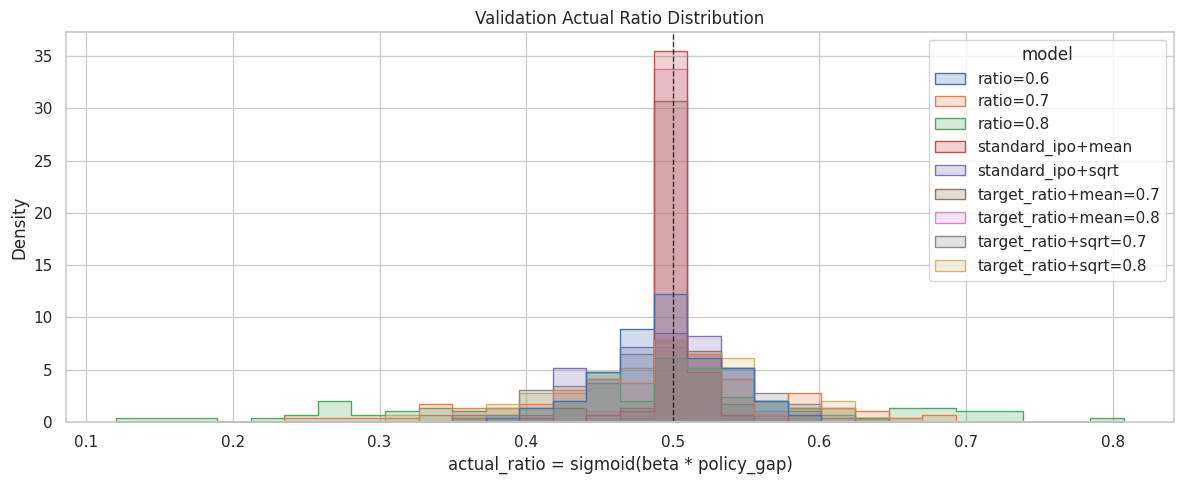

In [11]:
plt.figure(figsize=(12, 5))
if sns:
    sns.histplot(
        data=validation_metrics,
        x="actual_ratio",
        hue="model",
        element="step",
        stat="density",
        common_norm=False,
        bins=30,
    )
else:
    for model, mdf in validation_metrics.groupby("model"):
        plt.hist(mdf["actual_ratio"], bins=30, alpha=0.35, density=True, label=model)
    plt.legend()
plt.axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.7)
plt.title("Validation Actual Ratio Distribution")
plt.xlabel("actual_ratio = sigmoid(beta * policy_gap)")
plt.tight_layout()
plt.show()

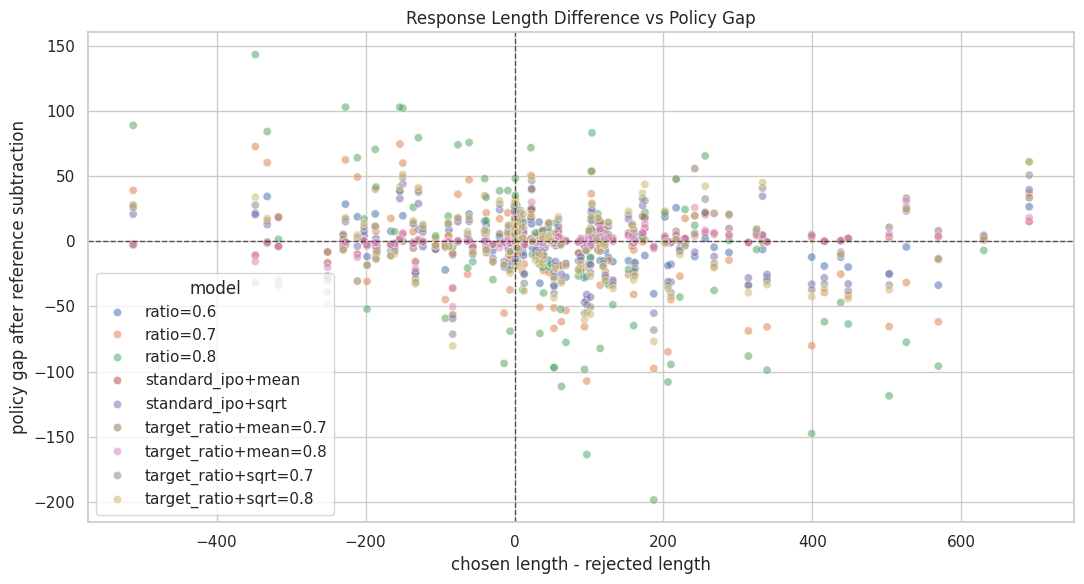

In [12]:
plot_df = validation_metrics.copy()
plt.figure(figsize=(11, 6))
if sns:
    sns.scatterplot(
        data=plot_df,
        x="length_diff",
        y="policy_gap",
        hue="model",
        alpha=0.55,
        s=35,
    )
else:
    for model, mdf in plot_df.groupby("model"):
        plt.scatter(mdf["length_diff"], mdf["policy_gap"], s=20, alpha=0.5, label=model)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
plt.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
plt.title("Response Length Difference vs Policy Gap")
plt.xlabel("chosen length - rejected length")
plt.ylabel("policy gap after reference subtraction")
plt.tight_layout()
plt.show()

In [13]:
# 길이 차이와 gap의 상관관계입니다. norm이 길이 영향을 줄였는지 확인하는 용도입니다.
length_gap_corr = (
    validation_metrics
    .groupby("model")
    .apply(lambda g: pd.Series({
        "corr_length_diff_policy_gap": g["length_diff"].corr(g["policy_gap"]),
        "mean_policy_gap": g["policy_gap"].mean(),
        "mean_actual_ratio": g["actual_ratio"].mean(),
    }))
    .reset_index()
    .sort_values("mean_actual_ratio", ascending=False)
)
length_gap_corr

,model,corr_length_diff_policy_gap,mean_policy_gap,mean_actual_ratio
5,target_ratio+mean=0.7,0.487620,1.419278,0.503539
6,target_ratio+mean=0.8,0.440270,0.751011,0.501887
3,standard_ipo+mean,0.442481,0.597601,0.501496
0,ratio=0.6,-0.361549,-1.933790,0.495201
4,standard_ipo+sqrt,-0.118107,-2.358219,0.494203
7,target_ratio+sqrt=0.7,-0.115954,-2.689325,0.493439
8,target_ratio+sqrt=0.8,-0.109169,-3.070173,0.492547
1,ratio=0.7,-0.423606,-4.620054,0.489044
2,ratio=0.8,-0.443868,-8.123539,0.482164


## 5. Layer-Wise Weight Delta Norm

각 fine-tuned 모델이 SFT init에서 layer별로 얼마나 이동했는지 봅니다.

- `delta_norm = ||W_model - W_sft||`
- `relative_delta_norm = ||W_model - W_sft|| / ||W_sft||`
- 첫 실행은 모델을 CPU에서 순차적으로 로드하므로 오래 걸릴 수 있습니다.
- 결과는 `outputs/analysis_ipo_variants/layerwise_weight_delta.csv`로 저장됩니다.

In [14]:
FORCE_RECOMPUTE_WEIGHTS = False
WEIGHT_MODELS = VALIDATION_MODELS

In [15]:
def layer_key(name):
    m = re.search(r"model\.layers\.(\d+)", name)
    if m:
        return f"layer_{int(m.group(1)):02d}"
    if name.startswith("model.embed_tokens"):
        return "embed"
    if name.startswith("model.norm"):
        return "final_norm"
    if name.startswith("lm_head"):
        return "lm_head"
    return "other"

def module_group(name):
    if ".self_attn." in name:
        return "attention"
    if ".mlp." in name:
        return "mlp"
    if ".input_layernorm" in name or ".post_attention_layernorm" in name or name.startswith("model.norm"):
        return "norm"
    if "embed_tokens" in name:
        return "embed"
    if "lm_head" in name:
        return "lm_head"
    return "other"

def compute_layerwise_weight_delta(models_df, selected_models, force=False):
    cache_path = ANALYSIS_ROOT / "layerwise_weight_delta.csv"
    if cache_path.exists() and not force:
        cached = pd.read_csv(cache_path)
        if set(selected_models).issubset(set(cached["model"].unique())):
            return cached[cached["model"].isin(selected_models)].copy()

    import torch
    from transformers import AutoModelForCausalLM

    print(f"Loading base SFT model on CPU: {SFT_MODEL_ID}")
    base_model = AutoModelForCausalLM.from_pretrained(SFT_MODEL_ID, trust_remote_code=True, torch_dtype=torch.float32, device_map="cpu")
    base_state = {k: v.detach().cpu() for k, v in base_model.state_dict().items()}
    del base_model
    gc.collect()

    all_rows = []
    selected_df = models_df[models_df["model"].isin(selected_models)].copy()
    for _, meta in selected_df.iterrows():
        print(f"Loading target model on CPU: {meta['model']}")
        target_model = AutoModelForCausalLM.from_pretrained(meta["model_path"], trust_remote_code=True, torch_dtype=torch.float32, device_map="cpu")
        accum = {}
        target_state = target_model.state_dict()
        for name, target_tensor in target_state.items():
            base_tensor = base_state.get(name)
            if base_tensor is None or base_tensor.shape != target_tensor.shape:
                continue
            lk = layer_key(name)
            mg = module_group(name)
            key = (lk, mg)
            if key not in accum:
                accum[key] = {"delta_sq": 0.0, "base_sq": 0.0, "param_count": 0}
            diff = (target_tensor.detach().cpu() - base_tensor).float()
            base_f = base_tensor.float()
            accum[key]["delta_sq"] += float(torch.sum(diff * diff).item())
            accum[key]["base_sq"] += float(torch.sum(base_f * base_f).item())
            accum[key]["param_count"] += int(diff.numel())
        del target_model
        gc.collect()

        for (lk, mg), vals in accum.items():
            delta_norm = math.sqrt(vals["delta_sq"])
            base_norm = math.sqrt(vals["base_sq"])
            all_rows.append({
                "model": meta["model"],
                "family": meta["family"],
                "objective": meta["objective"],
                "length_norm": meta["length_norm"],
                "target_ratio": meta["target_ratio"],
                "layer": lk,
                "module_group": mg,
                "delta_norm": delta_norm,
                "base_norm": base_norm,
                "relative_delta_norm": delta_norm / base_norm if base_norm else np.nan,
                "param_count": vals["param_count"],
            })

    result = pd.DataFrame(all_rows)
    result.to_csv(cache_path, index=False)
    return result

weight_delta = compute_layerwise_weight_delta(models, WEIGHT_MODELS, force=FORCE_RECOMPUTE_WEIGHTS)
weight_delta.head()

,model,family,objective,length_norm,target_ratio,layer,module_group,delta_norm,base_norm,relative_delta_norm,param_count
0,ratio=0.6,fixed_ratio,target_ratio,none,0.6,embed,embed,0.130965,376.066317,0.000348,155582464
1,ratio=0.6,fixed_ratio,target_ratio,none,0.6,layer_00,attention,0.047738,135.015793,0.000354,6291712
2,ratio=0.6,fixed_ratio,target_ratio,none,0.6,layer_00,mlp,0.056133,93.207633,0.000602,9437184
3,ratio=0.6,fixed_ratio,target_ratio,none,0.6,layer_00,norm,0.000903,17.505620,0.000052,2048
4,ratio=0.6,fixed_ratio,target_ratio,none,0.6,layer_01,attention,0.050988,91.902028,0.000555,6291712


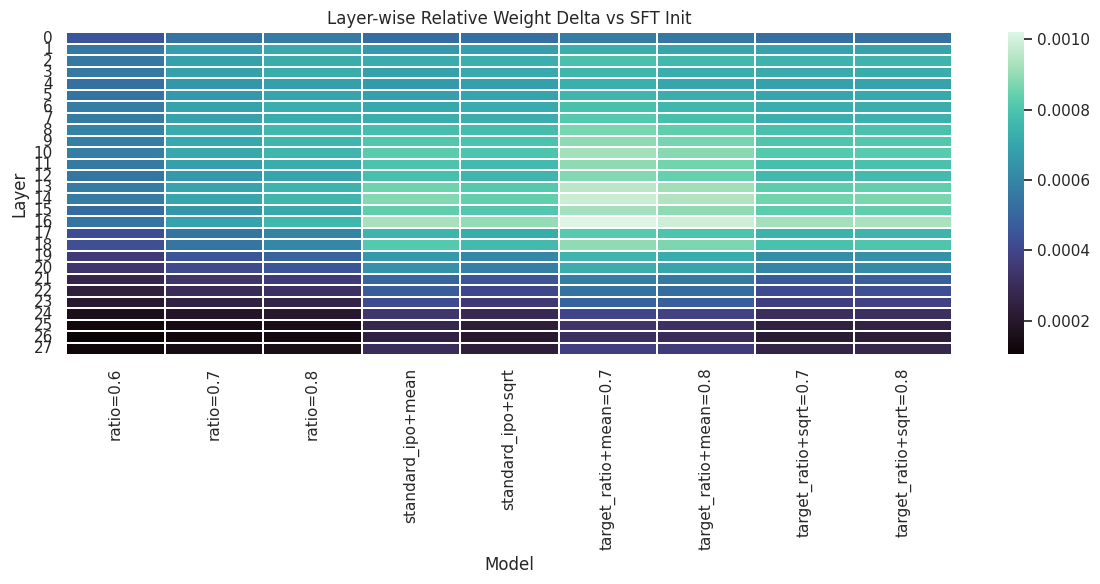

In [16]:
layer_only = weight_delta[weight_delta["layer"].str.startswith("layer_")].copy()
layer_only["layer_idx"] = layer_only["layer"].str.extract(r"(\d+)").astype(int)

layer_total = (
    layer_only
    .groupby(["model", "layer_idx"], as_index=False)
    .agg(delta_sq=("delta_norm", lambda x: np.sum(np.square(x))),
         base_sq=("base_norm", lambda x: np.sum(np.square(x))))
)
layer_total["delta_norm"] = np.sqrt(layer_total["delta_sq"])
layer_total["base_norm"] = np.sqrt(layer_total["base_sq"])
layer_total["relative_delta_norm"] = layer_total["delta_norm"] / layer_total["base_norm"]

pivot = layer_total.pivot(index="layer_idx", columns="model", values="relative_delta_norm")
plt.figure(figsize=(12, 6))
if sns:
    sns.heatmap(pivot, cmap="mako", linewidths=0.2)
else:
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label="relative delta norm")
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
    plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Layer-wise Relative Weight Delta vs SFT Init")
plt.xlabel("Model")
plt.ylabel("Layer")
plt.tight_layout()
plt.show()

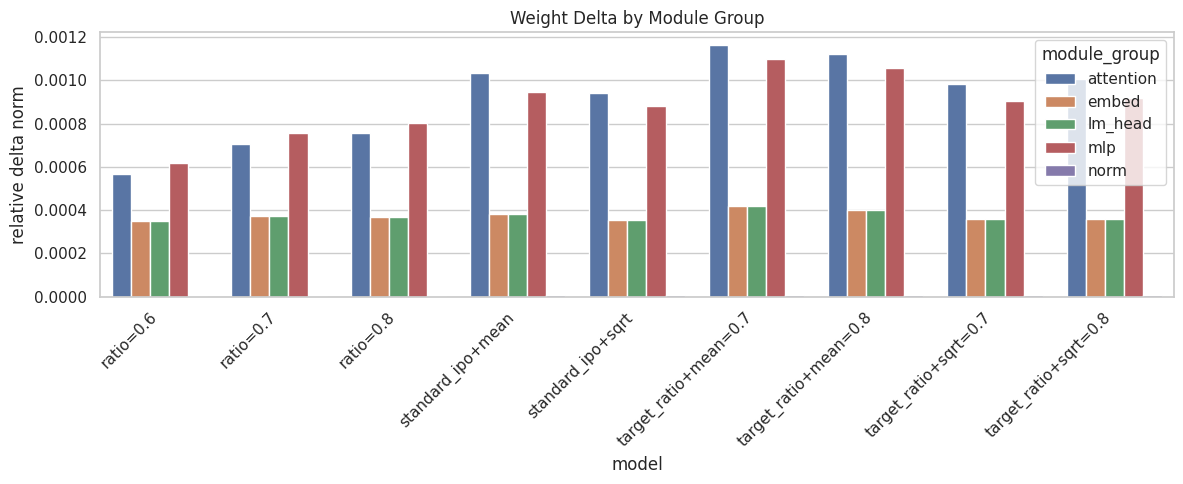

,model,module_group,delta_sq,base_sq,delta_norm,base_norm,relative_delta_norm
25,target_ratio+mean=0.7,attention,0.263219,1.941822e+05,0.513048,440.661078,0.001164
30,target_ratio+mean=0.8,attention,0.245535,1.941822e+05,0.495515,440.661078,0.001124
15,standard_ipo+mean,attention,0.207135,1.941822e+05,0.455121,440.661078,0.001033
40,target_ratio+sqrt=0.8,attention,0.196233,1.941822e+05,0.442982,440.661078,0.001005
35,target_ratio+sqrt=0.7,attention,0.188328,1.941822e+05,0.433968,440.661078,0.000985
20,standard_ipo+sqrt,attention,0.172824,1.941822e+05,0.415721,440.661078,0.000943
10,ratio=0.8,attention,0.110762,1.941822e+05,0.332809,440.661078,0.000755
5,ratio=0.7,attention,0.096287,1.941822e+05,0.310301,440.661078,0.000704
0,ratio=0.6,attention,0.062794,1.941822e+05,0.250587,440.661078,0.000569
26,target_ratio+mean=0.7,embed,0.024824,1.414259e+05,0.157555,376.066317,0.000419


In [17]:
module_summary = (
    weight_delta
    .groupby(["model", "module_group"], as_index=False)
    .agg(delta_sq=("delta_norm", lambda x: np.sum(np.square(x))),
         base_sq=("base_norm", lambda x: np.sum(np.square(x))))
)
module_summary["delta_norm"] = np.sqrt(module_summary["delta_sq"])
module_summary["base_norm"] = np.sqrt(module_summary["base_sq"])
module_summary["relative_delta_norm"] = module_summary["delta_norm"] / module_summary["base_norm"]

plt.figure(figsize=(12, 5))
if sns:
    sns.barplot(data=module_summary, x="model", y="relative_delta_norm", hue="module_group")
else:
    for group, gdf in module_summary.groupby("module_group"):
        plt.plot(gdf["model"], gdf["relative_delta_norm"], marker="o", label=group)
    plt.legend()
plt.xticks(rotation=45, ha="right")
plt.title("Weight Delta by Module Group")
plt.ylabel("relative delta norm")
plt.tight_layout()
plt.show()

module_summary.sort_values(["module_group", "relative_delta_norm"], ascending=[True, False])

## Quick Interpretation Checklist

- Benchmark delta heatmap에서 norm 모델이 어느 task에서 떨어지는지 확인합니다.
- actual ratio curve에서 norm 모델이 target ratio까지 올라가지 못하는지 봅니다.
- validation actual ratio histogram이 0.5 근처에 몰리면 preference gap이 충분히 형성되지 않은 것입니다.
- length difference vs gap scatter에서 길이 차이와 gap의 상관이 줄었는지 확인합니다.
- layer-wise delta norm이 작다면 normalization으로 인해 모델 업데이트 자체가 약해졌을 가능성이 있습니다.